# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [20]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [21]:
from sklearn.model_selection import train_test_split

#salary позволяет модели, зная местную валюту и зарплату в ней, тривиальным образом получать таргет
X = df[df.columns[(df.columns != 'salary') & (df.columns != 'salary_in_usd')]]
y = df['salary_in_usd']
X_train, _X_test, y_train, _y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(_X_test, _y_test, test_size = 0.5, random_state = 42)

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import numpy as np

categorical_features = X.select_dtypes(include="str").columns.tolist()

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_val_cat = encoder.transform(X_val[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

num_features = [c for c in X.columns if c not in categorical_features]
X_train_enc = np.hstack([X_train[num_features].values, X_train_cat])
X_val_enc = np.hstack([X_val[num_features].values, X_val_cat])
X_test_enc = np.hstack([X_test[num_features].values, X_test_cat])

model = LinearRegression()
model.fit(X_train_enc, y_train)

y_pred = model.predict(X_test_enc)

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', mean_squared_error(y_test, y_pred)**0.5)

MAPE:  0.37326943015237074
RMSE:  51564.89569000409


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [23]:
pip install xgboost


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: C:\Users\Виктор\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [40]:
from xgboost.sklearn import XGBRegressor
from itertools import product
import time

params = {
    'max_depth' : [1, 2, 3, 5],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'n_estimators' : [20, 50, 100, 150],
    'gamma' : [0.0001, 0.001, 0.01, 0.1]
}

best_mape, best_params = float('inf'), None
for md, lr, ne, gm in product(params['max_depth'], params['learning_rate'], params['n_estimators'], params['gamma']):
    model = XGBRegressor(
        max_depth=md,
        learning_rate=lr,
        n_estimators=ne,
        gamma=gm,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_train_enc, y_train)
    mape = mean_absolute_percentage_error(y_val, model.predict(X_val_enc))
    if mape < best_mape:
        best_mape = mape
        best_params = dict(max_depth=md, learning_rate=lr,
                           n_estimators=ne, gamma=gm)
print(best_params)

{'max_depth': 3, 'learning_rate': 0.3, 'n_estimators': 150, 'gamma': 0.0001}


In [41]:
model = XGBRegressor(**best_params)

t0 = time.time()
model.fit(X_train_enc, y_train)
train_time = time.time() - t0

t0 = time.time()
y_pred = model.predict(X_test_enc)
pred_time = time.time() - t0

print(f"Время обучения: {train_time:.3f} сек")
print(f"Время предсказания: {pred_time*1000:.2f} мс ({len(X_test_enc)} объектов)")

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', mean_squared_error(y_test, y_pred) ** 0.5)

Время обучения: 0.099 сек
Время предсказания: 2.00 мс (376 объектов)
MAPE:  0.33996304869651794
RMSE:  51034.21910835905


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [42]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: C:\Users\Виктор\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [43]:
from catboost import CatBoostRegressor

cat_features = X.select_dtypes(include="str").columns.tolist()
cat_indices = [X.columns.tolist().index(c) for c in cat_features]

params = {
    'depth' : [1, 2, 3, 5],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'iterations' : [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5],
}

best_mape, best_params = float('inf'), None

for dp, lr, it, l2 in product(params['depth'], params['learning_rate'],
                                params['iterations'], params['l2_leaf_reg']):
    m = CatBoostRegressor(
        depth=dp, learning_rate=lr, iterations=it, l2_leaf_reg=l2,
        cat_features=cat_indices, random_seed=42, verbose=0
    )
    m.fit(X_train, y_train, eval_set=(X_val, y_val))
    mape = mean_absolute_percentage_error(y_val, m.predict(X_val))
    if mape < best_mape:
        best_mape, best_params = mape, dict(depth=dp, learning_rate=lr,
                                             iterations=it, l2_leaf_reg=l2)

model = CatBoostRegressor(
    depth=best_params['depth'],
    learning_rate=best_params['learning_rate'],
    iterations=best_params['iterations'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    cat_features=cat_indices,
    random_seed=42,
    verbose=0,
)

t0 = time.time()
model.fit(X_train, y_train, eval_set=(X_val, y_val))
train_time = time.time() - t0

t0 = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - t0
print(best_params)

{'depth': 5, 'learning_rate': 0.1, 'iterations': 300, 'l2_leaf_reg': 1}


In [44]:
print(f"Время обучения:     {train_time:.3f} сек")
print(f"Время предсказания: {pred_time*1000:.2f} мс")

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', mean_squared_error(y_test, y_pred) ** 0.5)

Время обучения:     5.174 сек
Время предсказания: 2.00 мс
MAPE:  0.3568358239014712
RMSE:  49749.72176919569


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [45]:
from catboost import Pool

cat_features = X.select_dtypes(include="str").columns.tolist()

train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

params = {
    'depth' : [1, 2, 3, 5],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'iterations' : [100, 200, 300],
    'l2_leaf_reg': [1, 3, 5],
}

best_mape, best_params = float('inf'), None

for dp, lr, it, l2 in product(params['depth'], params['learning_rate'],
                                params['iterations'], params['l2_leaf_reg']):
    m = CatBoostRegressor(
        depth=dp, learning_rate=lr, iterations=it, l2_leaf_reg=l2,
        cat_features=cat_indices, random_seed=42, verbose=0
    )
    m.fit(train_pool, eval_set=val_pool)
    mape = mean_absolute_percentage_error(y_val, m.predict(val_pool))
    if mape < best_mape:
        best_mape, best_params = mape, dict(depth=dp, learning_rate=lr,
                                             iterations=it, l2_leaf_reg=l2)
print(best_params)
model = CatBoostRegressor(
    **best_params, 
    random_seed=42,
    verbose=0,
)

t0 = time.time()
model.fit(train_pool, eval_set=val_pool)
train_time = time.time() - t0

t0 = time.time()
y_pred = model.predict(test_pool)
pred_time = time.time() - t0

print(f"Время обучения: {train_time:.3f} сек")
print(f"Время предсказания: {pred_time*1000:.2f} мс")

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', mean_squared_error(y_test, y_pred) ** 0.5)

{'depth': 5, 'learning_rate': 0.1, 'iterations': 300, 'l2_leaf_reg': 1}
Время обучения: 5.218 сек
Время предсказания: 1.00 мс
MAPE:  0.3568358239014712
RMSE:  49749.72176919569


**Ответ:** качество осталось идентичным, однако время предсказания уменьшилось втрое благодаря тому, что теперь не нужно кодировать предварительно категориальные данные перед запуском самой модели.

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [46]:
from lightgbm import LGBMRegressor

cat_features = X.select_dtypes(include="object").columns.tolist()
for col in cat_features:
    X_train[col] = X_train[col].astype("category")
    X_val[col]   = X_val[col].astype("category")
    X_test[col]  = X_test[col].astype("category")

params = {
    'max_depth' : [1, 2, 3, 5],
    'learning_rate' : [0.05, 0.1, 0.2, 0.3],
    'n_estimators' : [20, 50, 100, 200, 300, 400],
    'leaves' : [31, 63]
}

best_mape, best_params = float('inf'), None
for md, lr, ne, lv in product(params['max_depth'], params['learning_rate'], params['n_estimators'], params['leaves']):
    model = LGBMRegressor(
        max_depth=md,
        learning_rate=lr,
        n_estimators=ne,
        leaves=lv,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    mape = mean_absolute_percentage_error(y_val, model.predict(X_val))
    if mape < best_mape:
        best_mape = mape
        best_params = dict(max_depth=md, learning_rate=lr,
                           n_estimators=ne, leaves=lv)
print(best_params)

C:\Users\Виктор\AppData\Local\Temp\ipykernel_8512\1586017330.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns.tolist()


{'max_depth': 2, 'learning_rate': 0.3, 'n_estimators': 300, 'leaves': 31}


In [47]:
model = LGBMRegressor(**best_params, random_state=42, verbose=-1)

t0 = time.time()
model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
train_time = time.time() - t0

t0 = time.time()
y_pred = model.predict(X_test)
pred_time = time.time() - t0

print(f"Время обучения: {train_time:.3f} сек")
print(f"Время предсказания: {pred_time*1000:.2f} мс")

print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))
print('RMSE: ', mean_squared_error(y_test, y_pred) ** 0.5)

Время обучения: 0.057 сек
Время предсказания: 6.00 мс
MAPE:  0.34300443925010665
RMSE:  49772.18884974949


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** если сравнивать с бенчмарком - линейной модели, то все модели бустинга работают в среднем лучше. По MAPE лучше всего работает XGBoost, у него очень маленькое время обучения, при этом самый большой RMSE. Наименьшие значения RMSE показывают CatBoost и LightGBM, при этом LightGBM показывает самое большое время предсказания из-за большого числа листьев. Если говорить о гиперпараметрах, то в случае с LightGBM основным параметром является количество листьев, то есть при небольшой глубине в сравнении с другими моделями дерево может быть таким же сложным. 

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [88]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [89]:
ratings = ratings.T

Выкиньте строку под названием `user`.

In [90]:
ratings = ratings.drop('user')
ratings

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
michal w. smith,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
群星,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agalloch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meshuggah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [91]:
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
rob zombie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [92]:
from sklearn.cluster import KMeans

kmeans = KMeans(5, random_state=42)
kmeans.fit(ratings)
kmeans_labels = pd.Series(kmeans.labels_, ratings.index)

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [93]:
kmeans_labels.value_counts()

3    882
0    115
4      1
2      1
1      1
Name: count, dtype: int64

**Ответ:** как-то не особо, мы получили один очень большой кластер, один маленький и три единичных объекта. Это могло получится из-за большой размерности, то есть все объекты находятся далеко друг от друга и воспринимаются как разные.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [94]:
kmeans_label_counts = kmeans_labels.value_counts()
kmeans_labels[kmeans_labels.isin(kmeans_label_counts[kmeans_label_counts == 1].index)]

the beatles     4
niИ             2
日dir en grey    1
dtype: int32

Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [95]:
listener_share = (ratings > 0).sum(axis=1) / ratings.shape[1]
mean_share = ratings.mean(axis=1)
stats = pd.DataFrame({
    'listener_share': listener_share,
    'mean_share': mean_share
}).sort_values('listener_share', ascending=False)
print(stats.head(10))

                       listener_share  mean_share
the beatles                    0.3342    0.018369
radiohead                      0.2778    0.011851
deathcab for cutie             0.1862    0.006543
coldplay                       0.1682    0.006030
modest mouse                   0.1628    0.005876
sufjan stevens                 0.1292    0.004969
dylan. bob                     0.1262    0.004963
red hot clili peppers          0.1258    0.003994
pink fluid                     0.1256    0.004909
kanye west                     0.1250    0.004641


**Ответ:** Битлов слушал каждый третий пользователь, и по вовлеченности пользователей они лидеры тоже.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [96]:
from sklearn.preprocessing import normalize

ratings_normal = pd.DataFrame(normalize(ratings), index=ratings.index, columns=ratings.columns)
ratings_normal

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,0.000000,0.000000,0.000000,0.0,0.012054,0.000000,0.0,0.0,0.025864,0.004880,...,0.000000,0.0,0.033554,0.010569,0.002199,0.004952,0.0,0.021302,0.0,0.000000
radiohead,0.009348,0.084688,0.000000,0.0,0.039505,0.002894,0.0,0.0,0.000000,0.008771,...,0.008120,0.0,0.000000,0.000000,0.005122,0.000000,0.0,0.000000,0.0,0.000000
deathcab for cutie,0.000000,0.017278,0.020144,0.0,0.024333,0.000000,0.0,0.0,0.000000,0.009391,...,0.085361,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.019622
coldplay,0.000000,0.000000,0.000000,0.0,0.011129,0.000000,0.0,0.0,0.000000,0.000000,...,0.144628,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
modest mouse,0.000000,0.000000,0.000000,0.0,0.010260,0.000000,0.0,0.0,0.000000,0.019597,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
michal w. smith,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
群星,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
agalloch,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
meshuggah,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000


Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [97]:
kmeans = KMeans(5, random_state=42)
kmeans.fit(ratings_normal)
kmeans_labels = pd.Series(kmeans.labels_, ratings.index)
kmeans_labels.value_counts()

4    486
1    162
3    140
2    133
0     79
Name: count, dtype: int64

**Ответ** ну теперь получше, кажется, что да, может быть полезной.

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [98]:
from scipy.spatial.distance import cosine

centroids = kmeans.cluster_centers_
distances_to_centroids: pd.Series = ratings_normal.apply(lambda v: cosine(v, centroids[kmeans_labels[v.name]]), axis=1)
central_bands = pd.DataFrame()
for val in range(5):
    central_bands[val] = distances_to_centroids[kmeans_labels == val].sort_values()[:10].index
central_bands

,0,1,2,3,4
0,nas,fall out boy,brand new,the beatles,radiohead
1,jay-z,the all-americian rejects,blink-182,the rolling stones,the arcade fire
2,kanye west,paramore,alkaline trio,dylan. bob,the shins
3,lupe the gorilla,kelly clarkson,against me!,who,sufjan stevens
4,a tribe called quest,john mayer,underoath,led zeppelin.,belle and sebastian
5,the roots featuring d'angelo,the fray,descendents,miles davis.,broken social scene
6,gangstarr,maroon5,new found glory,simon and garfunkel,the pixies
7,little brother,dashboard confesssional,less than jake,"young, neil",animal collective
8,lil' wayne,somethings corporate,thrice,pink fluid,modest mouse
9,murs and 9th wonder,coldplay,chiodos,velvet underground,spoon


**Ответ:** видно четкое жанровое различие, 0 - рэп и хип-хоп, 1 - поп-рок 00х, 2 - панк-рок, 3 - рок 1960х, 4 - инди-рок и альтернатива. Мы смогли разделить пользователей по реальным жанровым пристрастиям, и сможем настроить рекомендательные системы так, чтоб предлагать им музыкантов из того же кластера.

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

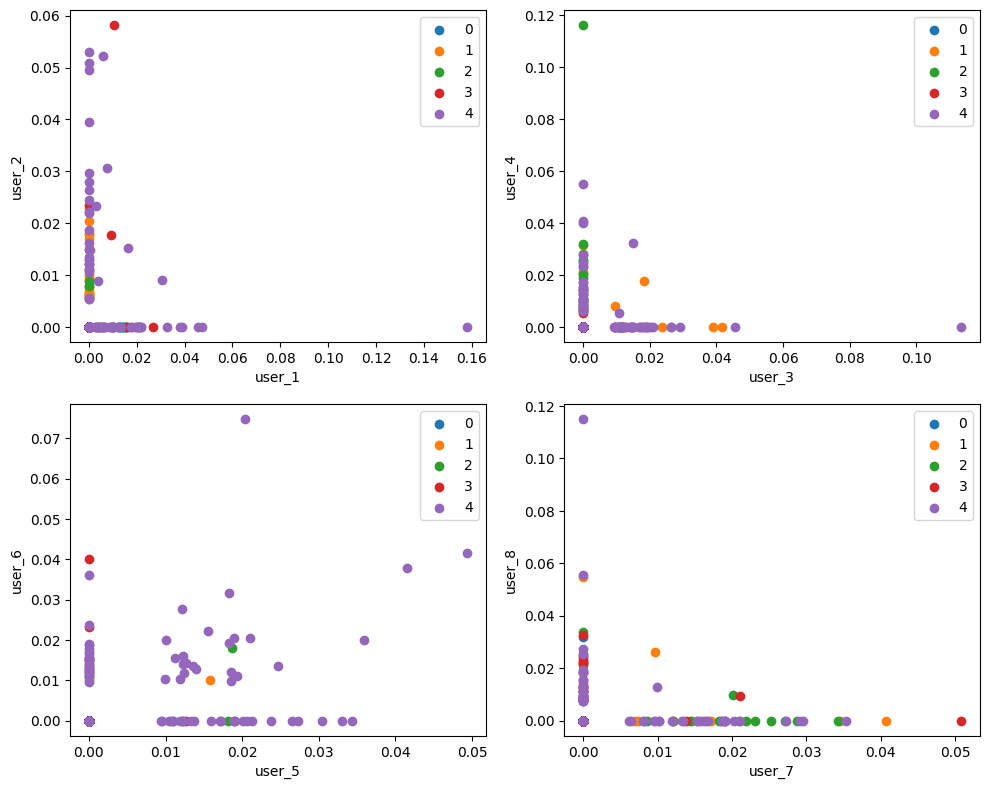

In [99]:
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

params = ratings.apply(lambda s: (s != 0).sum()).sort_values(ascending=False).head(8).index
param_names = {p: f'user_{i+1}' for i, p in enumerate(params)}
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs: np.ndarray
for j in range(5):
    relevant = ratings[kmeans_labels == j]
    for i, ax in zip(range(4), axs.flatten()):
        ax: Axes
        param_x = params[2*i]
        param_y = params[2*i+1]
        ax.scatter(relevant[param_x], relevant[param_y], label=j)
        ax.legend()
        ax.set_xlabel(param_names[param_x])
        ax.set_ylabel(param_names[param_y])
plt.tight_layout()
plt.show()

**Ответ:** не очень, пользователи слушают лишь очень небольшую выборку, поэтому это всё в конце концов улетает в (0, 0).

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

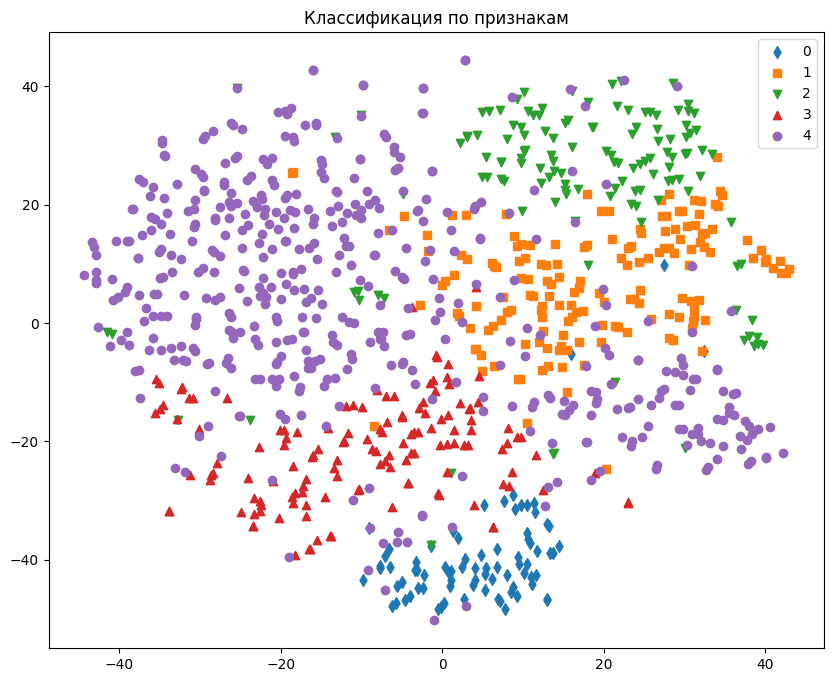

In [100]:
from sklearn.manifold import TSNE

MARKERS = ['d', 's', 'v', '^', 'o']
tsne = TSNE(random_state=239)
ratings_normal_tsne = tsne.fit_transform(ratings_normal)

plt.figure(figsize=(10, 8))
for v in range(5):
    relevant = ratings_normal_tsne[kmeans_labels == v]
    plt.scatter(*relevant.T, marker=MARKERS[v], label=v)
plt.legend()
plt.title("Классификация по признакам")
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [101]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}
for n_clusters in range(2, 101):
    kmeans = KMeans(n_clusters, random_state=42)
    labels = kmeans.fit_predict(ratings)
    score = silhouette_score(ratings, labels)
    silhouette_scores[n_clusters] = score

best_n = max(silhouette_scores, key=silhouette_scores.get)
print(f"Лучшее число кластеров: {best_n}")
print(f"Силуэт: {silhouette_scores[best_n]:.4f}")

Лучшее число кластеров: 3
Силуэт: 0.5664


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [104]:
kmeans = KMeans(best_n, random_state=42)
kmeans.fit(ratings_normal)
kmeans_labels = pd.Series(kmeans.labels_, ratings.index)
centroids = kmeans.cluster_centers_
distances_to_centroids: pd.Series = ratings_normal.apply(lambda v: cosine(v, centroids[kmeans_labels[v.name]]), axis=1)
central_bands = pd.DataFrame()
for val in range(best_n):
    central_bands[val] = distances_to_centroids[kmeans_labels == val].sort_values()[:10].index
central_bands

,0,1,2
0,nas,fall out boy,radiohead
1,kanye west,paramore,the arcade fire
2,jay-z,the all-americian rejects,belle and sebastian
3,a tribe called quest,dashboard confesssional,sufjan stevens
4,the roots featuring d'angelo,john mayer,the shins
5,metallica,kelly clarkson,the pixies
6,system of a down,maroon5,broken social scene
7,lupe the gorilla,coldplay,animal collective
8,mos def,the fray,deathcab for cutie
9,tool,the killers,modest mouse


**Ответ:** жанровое разделение осталось, но оно укрупнилось: 0 - рэп, хип-хоп и хард-рок - имеют общую аудиторию, можно рекомендовать всё сразу из этого кластера слушателям Канье (если сравнить со старой разбивкой, то это 0+2 кластер). 1 - поп-рок, в целом также всё, 2 - инди-рок и альтернатива.

Сделайте t-SNE визуализацию полученной кластеризации.

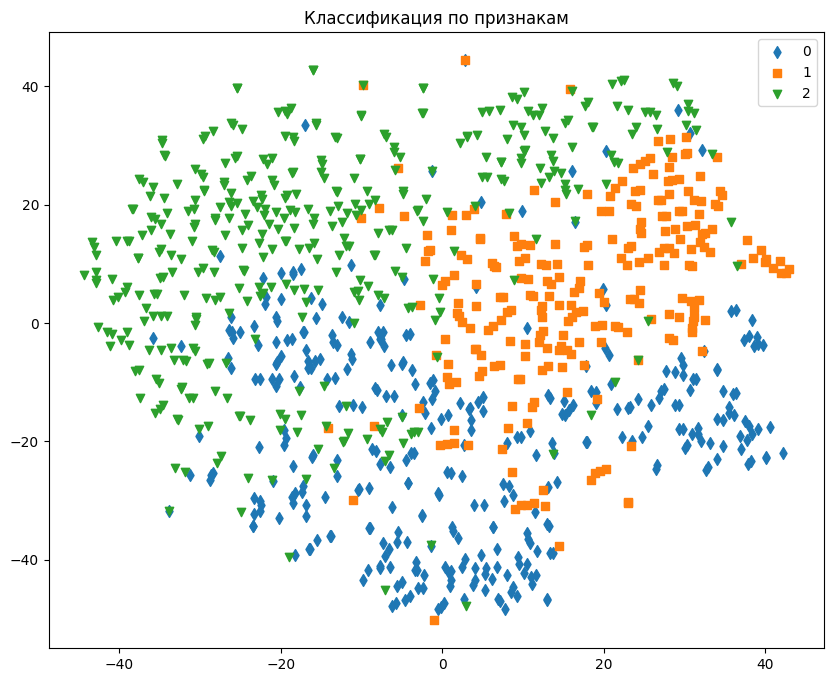

In [105]:
MARKERS = ['d', 's', 'v', '^', 'o']
tsne = TSNE(random_state=239)
ratings_normal_tsne = tsne.fit_transform(ratings_normal)

plt.figure(figsize=(10, 8))
for v in range(best_n):
    relevant = ratings_normal_tsne[kmeans_labels == v]
    plt.scatter(*relevant.T, marker=MARKERS[v], label=v)
plt.legend()
plt.title("Классификация по признакам")
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** ну у меня вышло три кластера только, не вижу смысла как-то красить это.